In [ ]:
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
import pandas as pd
import numpy as np
import torch
import os 
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [ ]:
# Load environment variables from a .env file

from dotenv import load_dotenv
load_dotenv()

True

### Data Paths Initialization & Loading

In [ ]:
# Load the dataset paths from environment variables

dataset_dir = os.getenv("DATASET_DIR")
datasplit_dir = os.getenv("DATASPLITS_DIR")

train_path = os.path.join(datasplit_dir, "mm_train.tsv")
test_path = os.path.join(datasplit_dir, "mm_test.tsv")
val_path = os.path.join(datasplit_dir, "mm_val.tsv")

In [ ]:
# Load the training, validation, and test splits as DataFrames

df_train = pd.read_csv(train_path, sep = "\t")
df_test = pd.read_csv(test_path, sep = "\t")
df_val = pd.read_csv(val_path, sep = "\t")

print(df_train.shape)
print(df_train.columns)


(11642, 4)
Index(['cleaned_tweet_text', 'image_path', 'mm_info', 'mm_human'], dtype='object')


In [ ]:
# Select computation device (GPU if available)

device = "cuda" if torch.cuda.is_available() else "cpu"

### Text Embedding Extraction
#### We use a pre-trained RoBERTa model to extract [CLS] token embeddings for each text in the dataset.


In [ ]:
def extract_roberta_embeddings(df, text_column="tweet_text", model_name="roberta-base", batch_size=32):

    # Load tokenizer and model
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    model.to(device)
    model.eval()

    all_embeddings = []

    # Elaborazione a batch
    texts = df[text_column].tolist()
    for i in tqdm(range(0, len(texts), batch_size), desc="Extracting embeddings"):
        batch_texts = texts[i:i+batch_size]
        encodings = tokenizer(batch_texts, padding=True, truncation=True, return_tensors="pt", max_length=128)
        encodings = {k: v.to(device) for k, v in encodings.items()}

        with torch.no_grad():
            outputs = model(**encodings)
            cls_embeddings = outputs.last_hidden_state[:, 0, :]  # [CLS] token
            all_embeddings.append(cls_embeddings.cpu().numpy())

    # Concatena tutti gli embeddings
    all_embeddings = np.concatenate(all_embeddings, axis=0)
    emb_df = pd.DataFrame(all_embeddings)
    emb_df.index = df.index  # mantiene gli stessi indici del df originale
    return emb_df


#### We apply the `extract_roberta_embeddings` function to each dataset split to obtain vector representations from RoBERTa.


In [ ]:
df_train_text_embeddings = extract_roberta_embeddings(df=df_train, text_column="cleaned_tweet_text", model_name="roberta-base")
df_val_text_embeddings = extract_roberta_embeddings(df=df_val, text_column="cleaned_tweet_text", model_name="roberta-base")
df_test_text_embeddings = extract_roberta_embeddings(df=df_test, text_column="cleaned_tweet_text", model_name="roberta-base")

df_train_text_embeddings.shape

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Extracting embeddings: 100%|██████████| 364/364 [00:25<00:00, 14.01it/s]
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Extracting embeddings: 100%|██████████| 78/78 [00:06<00:00, 12.58it/s]
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Extracting embeddings: 100%|███

(11642, 768)

### Image Embedding Extraction

#### This function extracts image embeddings using a pre-trained EfficientNetB0 model (without the classification head).
#### Optionally, data augmentation can be applied during embedding generation.


In [ ]:
def extract_efficientnet_embeddings(df, image_column="image_path", target_size=(224, 224), batch_size=32, apply_augmentation=False):

    # Carica EfficientNet senza top
    base_model = EfficientNetB0(include_top=False, weights='imagenet', pooling='avg')
    model = Model(inputs=base_model.input, outputs=base_model.output)

    embeddings = []

    paths = df[image_column].tolist()
    for i in tqdm(range(0, len(paths), batch_size), desc="Extracting image embeddings"):
        batch_paths = paths[i:i+batch_size]
        batch_images = []

        for path in batch_paths:
            try:
                img = image.load_img(path, target_size=target_size)
                img_array = image.img_to_array(img)

                # --- AUGMENTATION: flip, zoom, shift ---
                if apply_augmentation:
                    
                    data_augmentation = keras.Sequential([
                    keras.layers.RandomFlip("horizontal"),
                    keras.layers.RandomRotation(0.1),
                    keras.layers.RandomZoom(0.2),
                ])

                    # Espandi le dimensioni per simulare batch (richiesto da keras layers)
                    img_tensor = tf.expand_dims(img_array, axis=0)
                    img_tensor = data_augmentation(img_tensor)

                    # Rimuovi la dimensione extra
                    img_array = tf.squeeze(img_tensor, axis=0)
                
                img_array = preprocess_input(img_array)
                batch_images.append(img_array)
            except Exception as e:
                print(f"Errore con immagine {path}: {e}")
                batch_images.append(np.zeros((*target_size, 3)))  # fallback neutro

        batch_images = np.array(batch_images)
        batch_emb = model.predict(batch_images, verbose=0)
        embeddings.append(batch_emb)

    all_embeddings = np.concatenate(embeddings, axis=0)
    emb_df = pd.DataFrame(all_embeddings)
    emb_df.index = df.index
    return emb_df


#### We apply the `extract_efficientnet_embeddings` function to each dataset split to obtain vector representations from EfficientNet model.

In [ ]:
# Extract image embeddings for train, validation, and test splits

df_train_img_embeddings = extract_efficientnet_embeddings(df=df_train, image_column="image_path", apply_augmentation=True)
df_val_img_embeddings = extract_efficientnet_embeddings(df=df_val, image_column="image_path", apply_augmentation=False)
df_test_img_embeddings = extract_efficientnet_embeddings(df=df_test, image_column="image_path", apply_augmentation=False)

df_train_img_embeddings.shape

Extracting image embeddings:  41%|████      | 148/364 [03:53<05:28,  1.52s/it]c:\Users\mario\Desktop\Deep Learning\Progetto\multimodal-crisis-classification\deep_env2\lib\site-packages\PIL\Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Extracting image embeddings: 100%|██████████| 78/78 [00:58<00:00,  1.32it/s]


(11642, 1280)

### Early Fusion
#### We concatenate text and image embeddings to create a unified multimodal feature representation.


In [ ]:
# Combine text and image embeddings into a single feature vector
combined_train = np.concatenate([df_train_text_embeddings.to_numpy(), df_train_img_embeddings.to_numpy()], axis=1)
combined_val = np.concatenate([df_val_text_embeddings.to_numpy(), df_val_img_embeddings.to_numpy()], axis=1)
combined_test = np.concatenate([df_test_text_embeddings.to_numpy(), df_test_img_embeddings.to_numpy()], axis=1)

combined_train.shape

(11642, 2048)

In [ ]:
# Encode labels for both tasks (binary and multiclass)
le_info = LabelEncoder()
y_train_task1 = le_info.fit_transform(df_train["mm_info"])
y_val_task1 = le_info.transform(df_val["mm_info"])
y_test_task1 = le_info.transform(df_test["mm_info"])

# Task 2
le_human = LabelEncoder()
y_train_task2 = le_human.fit_transform(df_train["mm_human"])
y_val_task2 = le_human.transform(df_val["mm_human"])
y_test_task2 = le_human.transform(df_test["mm_human"])

### Multitask Fusion Model
#### This function builds a multitask neural network using early fusion features.
It has:
- A shared dense backbone,
- One binary classification head (task 1),
- One multiclass classification head (task 2).

In [ ]:
def build_multitask_fusion_model(input_dim, num_classes_task2, learning_rate=1e-3, dropout_rate=0.4):
    # Input combinato
    fusion_input = Input(shape=(input_dim,), name="fusion_input")
    
    # Shared layers
    x = Dense(256, activation='relu')(fusion_input)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)

    # Head 1 - binary (task 1)
    task1_out = Dense(1, activation='sigmoid', name="task1_output")(x)

    # Head 2 - multiclass (task 2)
    task2_out = Dense(num_classes_task2, activation='softmax', name="task2_output")(x)

    # Build model
    model = Model(inputs=fusion_input, outputs=[task1_out, task2_out])

    # Compile
    model.compile(
        optimizer=Adam(learning_rate),
        loss={
            "task1_output": "binary_crossentropy",
            "task2_output": "sparse_categorical_crossentropy"
        },
        metrics={
            "task1_output": ["accuracy"],
            "task2_output": ["accuracy"]
        }
    )

    return model


### Training Visualization
#### This function plots the training and validation loss and accuracy curves for both tasks.


In [52]:
def plot_training_history_multitask(history, title="Multitask Training"):
    """
    Plot accuracy and loss curves for each task (training and validation).
    """
    epochs = range(1, len(history.history['loss']) + 1)

    plt.figure(figsize=(16, 6))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['loss'], label='Total Train Loss')
    plt.plot(epochs, history.history['val_loss'], label='Total Val Loss')
    plt.plot(epochs, history.history['task1_output_loss'], '--', label='Task 1 Train Loss')
    plt.plot(epochs, history.history['val_task1_output_loss'], '--', label='Task 1 Val Loss')
    plt.plot(epochs, history.history['task2_output_loss'], '--', label='Task 2 Train Loss')
    plt.plot(epochs, history.history['val_task2_output_loss'], '--', label='Task 2 Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['task1_output_accuracy'], label='Task 1 Train Acc')
    plt.plot(epochs, history.history['val_task1_output_accuracy'], label='Task 1 Val Acc')
    plt.plot(epochs, history.history['task2_output_accuracy'], label='Task 2 Train Acc')
    plt.plot(epochs, history.history['val_task2_output_accuracy'], label='Task 2 Val Acc')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()


### Model Evaluation
#### This function computes and prints classification metrics (accuracy, precision, recall, F1-score) and displays confusion matrices for both tasks.


In [53]:
def evaluate_multitask_model(model, X_test, y_test_task1, y_test_task2, label_encoder_task1=None, label_encoder_task2=None):
    """
    Valuta un modello multitask su entrambi i task e stampa:
    - Accuracy, Precision, Recall, F1
    - Matrice di confusione
    """
    # Predizioni
    y_pred_task1, y_pred_task2 = model.predict(X_test)

    # Task 1 (binario)
    y_pred_task1_cls = (y_pred_task1 > 0.5).astype(int)

    print("\n📊 Task 1 - Informative vs Not Informative")
    print("Accuracy :", accuracy_score(y_test_task1, y_pred_task1_cls))
    print("Precision:", precision_score(y_test_task1, y_pred_task1_cls))
    print("Recall   :", recall_score(y_test_task1, y_pred_task1_cls))
    print("F1-score :", f1_score(y_test_task1, y_pred_task1_cls))

    cm1 = confusion_matrix(y_test_task1, y_pred_task1_cls)
    disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=label_encoder_task1.classes_ if label_encoder_task1 else None)
    disp1.plot(cmap='Blues')
    plt.title("Task 1 - Confusion Matrix")
    plt.show()

    # Task 2 (multiclasse)
    y_pred_task2_cls = np.argmax(y_pred_task2, axis=1)

    print("\n📊 Task 2 - Humanitarian Categories")
    print("Accuracy :", accuracy_score(y_test_task2, y_pred_task2_cls))
    print("Precision:", precision_score(y_test_task2, y_pred_task2_cls, average='macro'))
    print("Recall   :", recall_score(y_test_task2, y_pred_task2_cls, average='macro'))
    print("F1-score :", f1_score(y_test_task2, y_pred_task2_cls, average='macro'))

    cm2 = confusion_matrix(y_test_task2, y_pred_task2_cls)
    disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=label_encoder_task2.classes_ if label_encoder_task2 else None)
    disp2.plot(cmap='Blues', xticks_rotation=45)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.title("Task 2 - Confusion Matrix")
    plt.show()


### Model Training
#### We build the multitask model using early fusion features and train it with both binary and multiclass targets.
#### Early stopping is used to prevent overfitting.


In [ ]:
# Define input size and number of classes
input_dim = combined_train.shape[1]
num_classes_task2 = len(np.unique(y_train_task2))

model = build_multitask_fusion_model(input_dim, num_classes_task2)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Training
history = model.fit(
    x=combined_train,
    y={
        "task1_output": y_train_task1,
        "task2_output": y_train_task2
    },
    validation_data=(
        combined_val,
        {
            "task1_output": y_val_task1,
            "task2_output": y_val_task2
        }
    ),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 2.3663 - task1_output_accuracy: 0.6468 - task1_output_loss: 0.7033 - task2_output_accuracy: 0.4234 - task2_output_loss: 1.6630 - val_loss: 1.3970 - val_task1_output_accuracy: 0.8132 - val_task1_output_loss: 0.3953 - val_task2_output_accuracy: 0.6116 - val_task2_output_loss: 1.0017
Epoch 2/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.5432 - task1_output_accuracy: 0.7996 - task1_output_loss: 0.4265 - task2_output_accuracy: 0.5719 - task2_output_loss: 1.1167 - val_loss: 1.2888 - val_task1_output_accuracy: 0.8357 - val_task1_output_loss: 0.3656 - val_task2_output_accuracy: 0.6553 - val_task2_output_loss: 0.9231
Epoch 3/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.3660 - task1_output_accuracy: 0.8275 - task1_output_loss: 0.3827 - task2_output_accuracy: 0.6332 - task2_output_loss: 0.9833 - val_loss: 1.2696 - val_task1_output_accuracy: 0.8365 - val_task1_output_loss: 0.3677 - val_task2_output_accuracy: 0.6629 - val_

dict_keys(['loss', 'task1_output_accuracy', 'task1_output_loss', 'task2_output_accuracy', 'task2_output_loss', 'val_loss', 'val_task1_output_accuracy', 'val_task1_output_loss', 'val_task2_output_accuracy', 'val_task2_output_loss'])


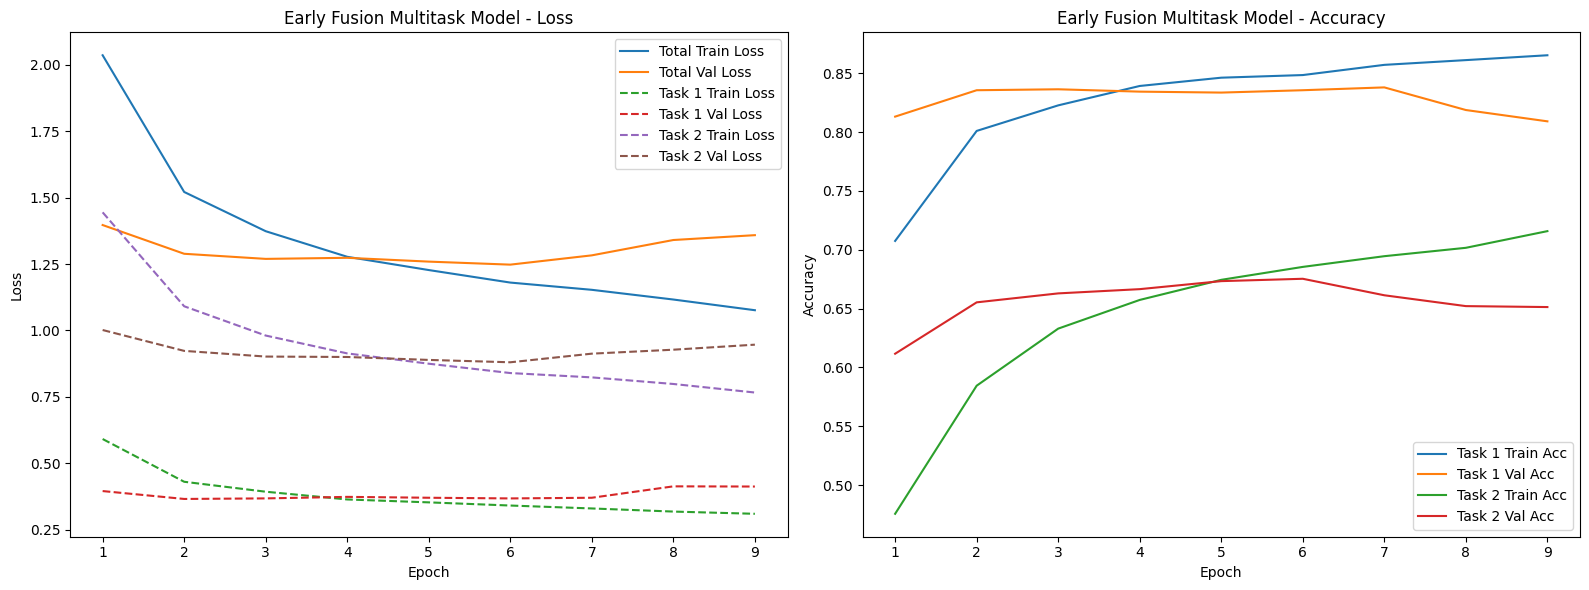

In [ ]:
# Visualize training and validation curves
print(history.history.keys())
plot_training_history_multitask(history, title="Early Fusion Multitask Model")

## Early Fusion Multimodal Classification

This notebook demonstrates a multimodal classification pipeline using early fusion of text and image data.  
We use:

- RoBERTa for extracting text embeddings,
- EfficientNetB0 for image embeddings,
- A shared neural network with two classification heads for multitask learning.

The tasks are:
- Task 1: Binary classification (Informative vs Not Informative),
- Task 2: Multiclass classification (Humanitarian category).

We evaluate the model using accuracy, precision, recall, F1-score, and confusion matrices.


78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

📊 Task 1 - Informative vs Not Informative
Accuracy : 0.8569138276553107
Precision: 0.7628676470588235
Recall   : 0.645412130637636
F1-score : 0.6992417860151643


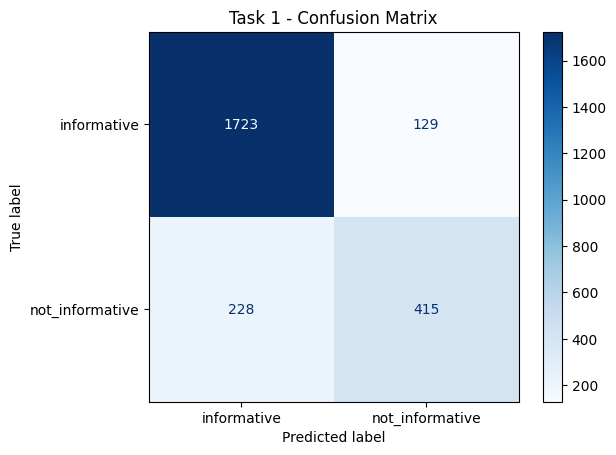


📊 Task 2 - Humanitarian Categories
Accuracy : 0.6813627254509018
Precision: 0.6389162361652451
Recall   : 0.6086462425936728
F1-score : 0.6157944333683197


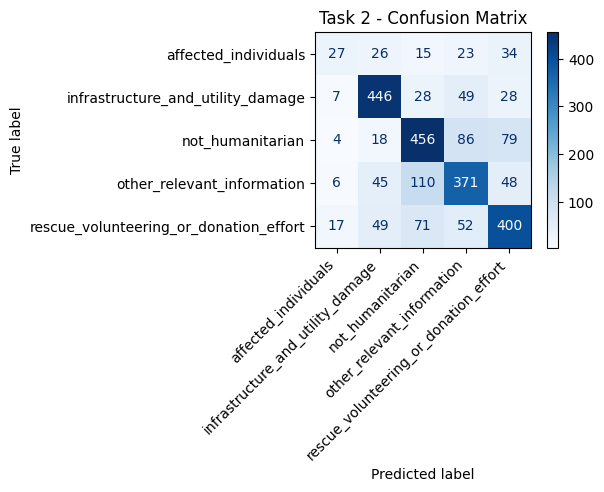

In [ ]:
# Evaluate the model on the test set
evaluate_multitask_model(
    model=model,
    X_test=combined_test,
    y_test_task1=y_test_task1,
    y_test_task2=y_test_task2,
    label_encoder_task1=le_info,
    label_encoder_task2=le_human
)